# Implied volatility solver

Runs `implied_vol.py` against a real SPX snapshot: how often Newton succeeds, when it
falls back to bisection, and why. Uses the sample snapshot committed in
`data/snapshots/`, so no internet is needed.

In [6]:
import sys

sys.path.insert(0, "..")  # optionsengine lives one level up, next to notebooks/

import pandas as pd
import matplotlib.pyplot as plt
from optionsengine import config
from optionsengine.quotes import clean_quotes
from optionsengine.validation import add_our_iv, method_distribution

## Load and clean the snapshot

One moment of the SPX chain, pulled live and committed to the repo. `clean_quotes` adds
years to expiry and the forward price, drops quotes with a missing, crossed, or
too-wide bid/ask, and keeps only OTM options: calls above the forward, puts below.

In [7]:
raw = pd.read_csv("../data/snapshots/sample_spx_20260827_1349.csv")
raw["asof"] = pd.to_datetime(raw["asof"])

quotes = clean_quotes(raw, weekly_root=config.ACTIVE.weekly_root,
                       monthly_root=config.ACTIVE.monthly_root,
                       am_hour=config.AM_SETTLEMENT_HOUR, pm_hour=config.PM_SETTLEMENT_HOUR,
                       r=config.r)
print(f"{len(raw)} raw rows -> {len(quotes)} after cleaning")

9902 raw rows -> 5802 after cleaning


## Solve implied volatility

One call per row: Newton-Raphson first, bisection if Newton's vega floor trips.

In [8]:
quotes = add_our_iv(quotes, config.r)

for method, fraction in method_distribution(quotes).items():
    print(f"{method:<10}{fraction:.1%}")

newton    54.2%
bisection 45.8%


## Why bisection happens

Newton gives up when vega is too small to trust: the price barely moves with volatility,
so its slope tells Newton almost nothing. That happens for options with little time left
and far from the money, so bisection cases should skew shorter-dated and further
out-of-the-money than Newton cases.

In [9]:
quotes["moneyness_distance"] = (quotes["strike"] / quotes["forward"] - 1).abs()
quotes.groupby("iv_method")[["years_to_expiry", "moneyness_distance"]].mean().round(3)

,years_to_expiry,moneyness_distance
iv_method,,
bisection,0.203,0.110
newton,0.322,0.036


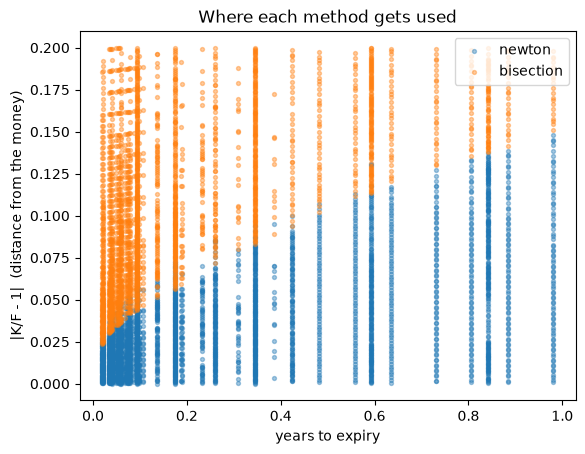

In [10]:
newton = quotes[quotes["iv_method"] == "newton"]
bisection = quotes[quotes["iv_method"] == "bisection"]

fig, ax = plt.subplots()
ax.scatter(newton["years_to_expiry"], newton["moneyness_distance"], s=8, alpha=0.4, label="newton")
ax.scatter(bisection["years_to_expiry"], bisection["moneyness_distance"], s=8, alpha=0.4, label="bisection")
ax.set_title("Where each method gets used")
ax.set_xlabel("years to expiry")
ax.set_ylabel("|K/F - 1|  (distance from the money)")
ax.legend()
plt.show()

Each point is one solved quote. Newton (blue) fills the region close to the money at
every time to expiry. Bisection (orange) takes over further out, and does so at a
smaller distance from the money the shorter the time to expiry, which is why Newton's
region forms a widening wedge. That shape can be explained by that vega
shrinks for short-dated, far-out-of-the-money options, so that's exactly where
Newton's step becomes unreliable and bisection has to take over.

## Next

`03_live_surface.ipynb` builds the actual IV surface from these solved quotes, and looks
at the error against Yahoo's own IV.